# Иследовательский анализ сервиса Яндекс Афиша 

Автор:Флоря Виктория Александровна  
Дата: 19.06.2026

# Введение

**Цель проекта:** провести исследовательский анализ данных сервиса «Яндекс Афиша», чтобы выяснить причины изменения пользовательского спроса и получить практические insights для продуктового отдела.

Было выявлено общее изменение в пользовательском спросе сервиса Яндекс Афиша. Причины этого пока неясны. Сработал фактор сезонности, и пользователи поменяли предпочтения? Или изменилась аудитория? Следует также разобраться, какие события стали привлекать больше зрителей, а какие организаторы и площадки выбились в лидеры. А также понять, отличаются ли своей активностью пользователи мобильных устройств от клиентов, которые бронируют билеты со стационарного компьютера.

# Содержание

1. Загрузка данных и знакомство с ними  
2. Предобработка данных и подготовка их к исследованию  
3. Исследовательский анализ данных  
   3.1. Анализ распределения заказов по сегментам и их сезонны  
   3.2. Осенняя активность пользователей  
   3.3. Популярные события и партнёрые изменения  
4. Статистический анализ данных  
5. Общий вывод и рекомендации

# Описание данных

Представлены данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Их вы уже использовали в предыдущей части проекта.   
Основные датасеты `final_tickets_orders_df.csv` и `final_tickets_events_df.csv`.  

Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета соответствуют таблице purchases:  

•	`order_id` — уникальный идентификатор заказа.  
•	`user_id` — уникальный идентификатор пользователя.  
•	`created_dt_msk` — дата создания заказа (московское время).  
•	`created_ts_msk` — дата и время создания заказа (московское время).  
•	`event_id` — идентификатор мероприятия из таблицы events.  
•	`cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.  
•	`age_limit` — возрастное ограничение мероприятия.  
•	`currency_code` — валюта оплаты, например rub для российских рублей.  
•	`device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.  
•	`revenue` — выручка от заказа.  
•	`service_name` — название билетного оператора.  
•	`tickets_count` — количество купленных билетов.  
•	`total` — общая сумма заказа.  
В данные также был добавлен столбец `days_since_prev` с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.  

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Из данных исключили фильмы, ведь, как было видно на дашборде, событий такого типа не так много. Датасет содержит такие поля:  
•	`event_id` — уникальный идентификатор мероприятия.  
•	`event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.  
•	`event_type_description` — описание типа мероприятия.  
•	`event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.  
•	`organizers` — организаторы мероприятия.  
•	`region_name` — название региона.  
•	`city_name` — название города.  
•	`venue_id` — уникальный идентификатор площадки.  
•	`venue_name` — название площадки.  
•	`venue_address` — адрес площадки.  


Датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год.   
Значения в рублях представлено для 100 тенге.   
Датасет содержит такие поля:  
•	`nominal` — номинал (100 тенге).  
•	`data` — дата.  
•	`curs` — курс тенге к рублю.  
•	`cdx` — обозначение валюты (kzt).  
Конвертируем казахстанских тенге в российские рубли для удобства.


# 1.Загрузка данных и знакомство с ними

In [1]:
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, mannwhitneyu, shapiro, levene

In [3]:
# Загружаем данные из исхлдных датасетов
orders_df = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge_df = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

Датафрейм `orders_df`:

In [4]:
# Выводим первые строки датафрейма orders_df на экран 
orders_df.head(5)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [5]:
# Выводим информацию о датафрейме orders_df на экран
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датафрейм events_df:

In [6]:
# Выводим первые строки датафрейма events_df на экран
events_df.head(5)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [7]:
# Выводим информацию о датафрейме events_df на экран
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датафрейм tenge_df:

In [8]:
# Выводим первые строки датафрейма tenge_df на экран
tenge_df.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [9]:
# Выводим информацию о датафрейме tenge_df на экран
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [10]:
# Статистика по количественным признакам
orders_df.describe()

,order_id,event_id,age_limit,revenue,tickets_count,total,days_since_prev
count,2.908490e+05,290849.000000,290849.000000,290849.000000,290849.000000,290849.000000,268909.000000
mean,4.326812e+06,438079.127702,10.211278,625.083054,2.754230,7526.465613,3.222525
std,2.497578e+06,147396.389016,6.518124,1227.316214,1.170467,15328.267730,11.355158
min,1.000000e+00,4436.000000,0.000000,-90.760000,1.000000,-358.850000,0.000000
25%,2.164039e+06,361961.000000,6.000000,116.790000,2.000000,2156.870000,0.000000
50%,4.327816e+06,498329.000000,12.000000,355.340000,3.000000,4771.390000,0.000000
75%,6.488606e+06,546284.000000,16.000000,809.750000,4.000000,8955.950000,1.000000
max,8.653108e+06,592325.000000,18.000000,81174.540000,57.000000,811745.400000,148.000000


In [11]:
# Проверим период дат
print("Даты заказов от", orders_df['created_dt_msk'].min(), "до", orders_df['created_dt_msk'].max())
print("Даты курса от", tenge_df['data'].min(), "до", tenge_df['data'].max())

Даты заказов от 2024-06-01 до 2024-10-31
Даты курса от 2024-01-10 до 2024-12-31


<font color='green'> Датафрейм `orders_df`.      
- Общее количество записей: в датафрейме 290 849 записей.  
- Количество столбцов: всего 14 столбцов, которые содержат различные типы данных (int64, float64, object).  
- Типы данных столбцов:  
   Числовые типы (int64 и float64) присутствуют в столбцах `order_id`, `age_limit`, `tickets_count`, `revenue`, `total` и `days_since_prev`.  
   Строковые типы (object) в столбцах `user_id`, `created_dt_msk`, `created_ts_msk`, `cinema_circuit`, `currency_code`, `device_type_canonical`, `service_name`.  
- Наличие пропущенных значений: столбец `days_since_prev` имеет 268 909 непустых значений, что указывает на наличие пропущенных данных в этом столбце.  

Датафрейм `events_df`.    
- Общее количество записей: в датафрейме 22 427 записей.  
- Количество столбцов: всего 11 столбцов, которые содержат различные типы данных (int64, object).  
- Типы данных столбцов:  
  Числовые типы (int64) присутствуют в столбцах `event_id`, `city_id`, `venue_id`.  
  Строковые типы (object) в столбцах `event_name`, `event_type_description`, `event_type_main`, `organizers`, `region_name`, `city_name`, `venue_name`, `venue_address`.  
- Наличие пропущенных значений: во всех столбцах нет пропущенных значений, так как указано, что для каждого столбца количество непустых значений равно 22 427.  

Датафрейм `tenge_df`.
- Общее количество записей: в датафрейме 357 записей.
- Количество столбцов: всего 4 столбца.
- Типы данных столбцов:
  Числовые типы (int64 и float64) присутствуют в столбцах nominal и curs.
</font>

# 2. Предобработка данных и подготовка их к исследованию

2.1. Сначала убедимся, что во всех столбцах, кроме `days_since_prev`, нет пропусков:

In [12]:
# Проверяем пропуски в заказах (датафрейм orders_df )
missing_orders = orders_df.isnull().sum()
print("Пропуски в orders_df:")
print(missing_orders)

# Проверяем пропуски в событиях (датафрейм events_df)
missing_events = events_df.isnull().sum()
print("\nПропуски в events_df:")
print(missing_events)
assert missing_events.sum() == 0  # в событиях пропусков быть не должно

Пропуски в orders_df:
order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

Пропуски в events_df:
event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64


In [13]:
# Проверяем пропуски в датафрейме tenge_df
display(tenge_df.isnull().sum())

data       0
nominal    0
curs       0
cdx        0
dtype: int64

2.2 Изучим значения в ключевых столбцах:

In [14]:
# Проверим уникальные значения в категориальных столбцах
print("Уникальные валюты:", orders_df['currency_code'].unique())
print("Уникальные типы устройств:", orders_df['device_type_canonical'].unique())
print("Уникальные возрастные ограничения:", orders_df['age_limit'].unique())
print("Уникальные билетные операторы (первые 10):", orders_df['service_name'].unique()[:10])

# Нормализация: все значения уже корректны, ничего менять не нужно.
# Но проверим, нет ли пустых строк или 'nan' в строковых столбцах.
for col in ['cinema_circuit', 'service_name', 'device_type_canonical']:
    if orders_df[col].dtype == 'object':
        unique_vals = orders_df[col].unique()
        if '' in unique_vals or 'nan' in unique_vals:
            print(f"В столбце {col} есть пустые строки или 'nan'")
        else:
            print(f"Столбец {col} корректен")

Уникальные валюты: ['rub' 'kzt']
Уникальные типы устройств: ['mobile' 'desktop']
Уникальные возрастные ограничения: [16  0 18 12  6]
Уникальные билетные операторы (первые 10): ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры']
Столбец cinema_circuit корректен
Столбец service_name корректен
Столбец device_type_canonical корректен


In [15]:
orders_cleaned = orders_df.copy()
# 1. Статистические показатели для revenue (по валютам)
for currency in ['rub', 'kzt']:
    subset = orders_cleaned[orders_cleaned['currency_code'] == currency]['revenue']
    print(f"\nСтатистика для revenue ({currency}):")
    print(subset.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
    print(f"Количество записей: {len(subset)}")

# Статистика для tickets_count (общая)
print("\nСтатистика для tickets_count:")
print(orders_cleaned['tickets_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


Статистика для revenue (rub):
count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
90%        1276.150000
95%        1606.500000
99%        2569.594200
max       81174.540000
Name: revenue, dtype: float64
Количество записей: 285780

Статистика для revenue (kzt):
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
90%      13212.930000
95%      13784.260000
99%      17617.240000
max      26425.860000
Name: revenue, dtype: float64
Количество записей: 5069

Статистика для tickets_count:
count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
90%           4.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64


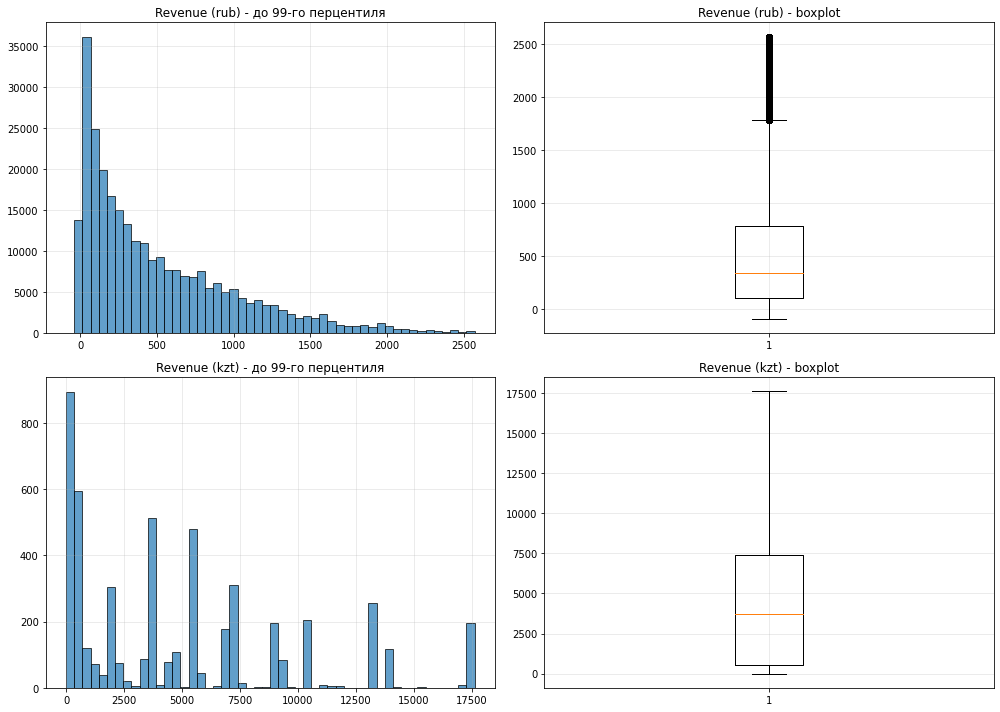

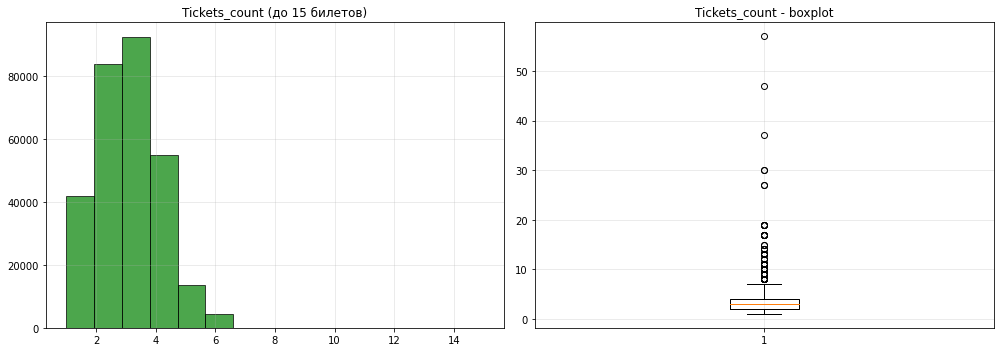

In [16]:
# 2. Визуализация распределений
# Строим визализацию график распределения и ящик с усами
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограммы revenue
for idx, currency in enumerate(['rub', 'kzt']):
    data = orders_df[orders_df['currency_code'] == currency]['revenue']
    data_clean = data[data <= data.quantile(0.99)]
    
    axes[idx, 0].hist(data_clean, bins=50, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Revenue ({currency}) - до 99-го перцентиля')
    axes[idx, 0].grid(True, alpha=0.3)
    
    axes[idx, 1].boxplot(data_clean)
    axes[idx, 1].set_title(f'Revenue ({currency}) - boxplot')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Распределение tickets_count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tickets_lim = orders_df[orders_df['tickets_count'] <= 15]['tickets_count']
axes[0].hist(tickets_lim, bins=15, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('Tickets_count (до 15 билетов)')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(orders_df['tickets_count'])
axes[1].set_title('Tickets_count - boxplot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Удаляем выбросы по колонке revenue
print("\n" + "=" * 60)
print("УДАЛЕНИЕ ВЫБРОСОВ ПО 99-МУ ПЕРЦЕНТИЛЮ")
print("=" * 60)

orders_cleaned = orders_df.copy()
total_removed = 0

for currency in ['rub', 'kzt']:
    # Считаем 99-й перцентиль на исходных данных
    mask = orders_df['currency_code'] == currency
    p99 = orders_df[mask]['revenue'].quantile(0.99)
    
    # Считаем сколько выбросов было
    outliers_count = (orders_df[mask]['revenue'] > p99).sum()
    total_removed += outliers_count
    
    # Удаляем выбросы из очищенного датафрейма
    orders_cleaned = orders_cleaned[~((orders_cleaned['currency_code'] == currency) & 
                                       (orders_cleaned['revenue'] > p99))]
    
    print(f"{currency}: удалено {outliers_count} выбросов (порог {p99:.2f})")

print(f"\nДо: {len(orders_df)}")
print(f"После: {len(orders_cleaned)}")
print(f"Удалено: {len(orders_df) - len(orders_cleaned)}")


УДАЛЕНИЕ ВЫБРОСОВ ПО 99-МУ ПЕРЦЕНТИЛЮ
rub: удалено 2858 выбросов (порог 2569.59)
kzt: удалено 29 выбросов (порог 17617.24)

До: 290849
После: 287962
Удалено: 2887


2.3. Проверка явных и неявных дубликатов:

In [18]:
# Проверим явные дубликаты - полные копии строк
explicit_dups = orders_cleaned.duplicated().sum()
print(f"Явных дубликатов: {explicit_dups}")

Явных дубликатов: 0


In [19]:
# Проверим неявные дубликаты - одинаковые заказы с одинаковым временем создания, без учета order_id
dup_cols = ['user_id', 'event_id','created_ts_msk', 'tickets_count', 'revenue', 'currency_code', 'device_type_canonical', 'total']
dup_mask = orders_cleaned.duplicated(subset=dup_cols, keep=False)
print("Неявных дубликатов (по основным полям):", dup_mask.sum())
# Посмотрим несколько примеров
orders_cleaned[dup_mask].sort_values(['user_id', 'created_ts_msk']).head(5)


Неявных дубликатов (по основным полям): 75


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,11.0
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,Лови билет!,3,19450.63,0.0
53715,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,Билеты в руки,2,6016.94,32.0


In [20]:
# Сначала посмотрим, сколько таких групп
dup_groups = orders_cleaned.groupby(dup_cols).size().reset_index(name='count')
groups_with_dups = dup_groups[dup_groups['count'] > 1]
print(f"Групп с неявными дубликатами: {len(groups_with_dups)}")

# Удаляем, оставляя первое вхождение
orders_cleaned = orders_cleaned.drop_duplicates(subset=dup_cols, keep='first')
print(f"Размер после удаления дубликатов: {len(dup_groups)}")


Групп с неявными дубликатами: 36
Размер после удаления дубликатов: 287923


<font color='green'> В ходе анализа данных были проверены как явные, так и неявные дубликаты.  

Явные дубликаты (полные копии строк) в датафрейме отсутствуют – duplicated().sum() вернул 0, что подтверждает корректность исходной выгрузки на уровне уникальности записей.
    

Неявные дубликаты – записи с одинаковыми значениями ключевых полей заказа (user_id, event_id, created_ts_msk, tickets_count, revenue, currency_code, device_type_canonical, total) – были обнаружены в количестве 75 строк, которые образовали 36 групп с повторениями (в некоторых группах встречалось до двух одинаковых заказов).  

После удаления неявных дубликатов с сохранением только первого вхождения в каждой группе размер датафрейма сократился с 287 962 до 287 923 записей (удалено 39 дублирующихся строк). Это незначительная доля от общего объёма данных (< 0,02 %), поэтому их исключение не повлияет на общие закономерности, но позволит избежать искажения агрегированных показателей (например, завышения числа заказов или выручки).  

Таким образом, данные были очищены от повторяющихся записей и готовы к дальнейшей обработке.  
</font>

2.4. Преобразование типов данных

In [21]:
# Проводим преобразования типов данных для даты и времени и понижаем разрядность для оптимизации памяти
print("\n" + "=" * 60)
print("ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ")
print("=" * 60)

# Преобразуем даты
orders_cleaned['created_dt_msk'] = pd.to_datetime(orders_cleaned['created_dt_msk'])
orders_cleaned['created_ts_msk'] = pd.to_datetime(orders_cleaned['created_ts_msk'])
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

print("Типы после преобразования дат:")
print(orders_cleaned[['created_dt_msk', 'created_ts_msk']].dtypes)
print(tenge_df['data'].dtype)

# Снижение размерности (опционально)
print("\n" + "=" * 60)
print("ОПТИМИЗАЦИЯ ПАМЯТИ")
print("=" * 60)

print(f"До оптимизации: {orders_cleaned.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Преобразуем только числовые колонки (user_id пропускаем, т.к. это строка)
for col in ['order_id', 'event_id', 'age_limit', 'tickets_count']:
    if col in orders_cleaned.columns:
        orders_cleaned[col] = pd.to_numeric(orders_cleaned[col], downcast='integer')
        print(f"  {col}: оптимизирован")

# Также можно оптимизировать float колонки
for col in ['revenue', 'total', 'days_since_prev']:
    if col in orders_cleaned.columns:
        orders_cleaned[col] = pd.to_numeric(orders_cleaned[col], downcast='float')
        print(f"  {col}: оптимизирован")

print(f"\nПосле оптимизации: {orders_cleaned.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Сэкономлено: {(136.52 - orders_cleaned.memory_usage(deep=True).sum() / 1024**2):.2f} MB")

print("\nТипы данных после оптимизации:")
print(orders_cleaned.dtypes)
print(tenge_df.dtypes)


ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ
Типы после преобразования дат:
created_dt_msk    datetime64[ns]
created_ts_msk    datetime64[ns]
dtype: object
datetime64[ns]

ОПТИМИЗАЦИЯ ПАМЯТИ
До оптимизации: 137.60 MB
  order_id: оптимизирован
  event_id: оптимизирован
  age_limit: оптимизирован
  tickets_count: оптимизирован
  revenue: оптимизирован
  total: оптимизирован
  days_since_prev: оптимизирован

После оптимизации: 128.27 MB
Сэкономлено: 8.25 MB

Типы данных после оптимизации:
order_id                          int32
user_id                          object
created_dt_msk           datetime64[ns]
created_ts_msk           datetime64[ns]
event_id                          int32
cinema_circuit                   object
age_limit                          int8
currency_code                    object
device_type_canonical            object
revenue                         float32
service_name                     object
tickets_count                      int8
total                           float32
days_

2.5. Объеденяем данные в один датафрейм `orders_final`.

In [22]:
# Объеденяем данные в один датафрейм
print("\n" + "=" * 60)
print("ОБЪЕДИНЕНИЕ ДАННЫХ")
print("=" * 60)

# Объединяем заказы с событиями по event_id
print(f"Размер orders_cleaned до объединения: {len(orders_cleaned)}")
print(f"Размер events_df: {len(events_df)}")

orders_with_events = orders_cleaned.merge(
    events_df, 
    on='event_id', 
    how='inner'
)

print(f"\nРазмер после объединения с событиями: {len(orders_with_events)}")

# Проверяем, все ли заказы получили информацию о событиях
missing_events = orders_with_events['event_type_main'].isna().sum()
if missing_events > 0:
    print(f" Внимание! {missing_events} заказов без информации о событиях")
else:
    print(" Все заказы успешно обогащены данными о событиях")

# Проверяем, не появились ли пропуски после объединения
print("\nПроверка пропусков после объединения:")
print(orders_with_events.isnull().sum().sort_values(ascending=False).head(10))

# Сохраняем объединенный датафрейм для дальнейшей работы
orders_final = orders_with_events.copy()
display(orders_final.head(5))

# еще раз убедимся в формате дат нового датафрейма
orders_final['created_dt_msk'] = pd.to_datetime(orders_final['created_dt_msk'])
orders_final['created_ts_msk'] = pd.to_datetime(orders_final['created_ts_msk'])

print(f"\n Итоговый размер данных: {len(orders_final)} записей")
print(f"Колонок в итоговом датафрейме: {len(orders_final.columns)}")


ОБЪЕДИНЕНИЕ ДАННЫХ
Размер orders_cleaned до объединения: 287923
Размер events_df: 22427

Размер после объединения с событиями: 287685
 Все заказы успешно обогащены данными о событиях

Проверка пропусков после объединения:
days_since_prev    21706
order_id               0
user_id                0
venue_name             0
venue_id               0
city_id                0
city_name              0
region_name            0
organizers             0
event_type_main        0
dtype: int64


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.420044,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.449951,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.420044,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.939941,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"



 Итоговый размер данных: 287685 записей
Колонок в итоговом датафрейме: 24


2.6. Создание новых столбцов `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`.

In [23]:
# Создаём новые столбцы
print("\n" + "=" * 60)
print("СОЗДАНИЕ НОВЫХ СТОЛБЦОВ")
print("=" * 60)

# Создаём копию датафрейма
orders_final = orders_with_events.dropna(subset=['event_type_main']).copy()

# 1. Конвертируем валюту
print("\n 1. Конвертация валюты в рубли (revenue_rub) ")

# Проверяем корректность курсов
if (tenge_df['curs'] <= 0).any():
    print("Внимание: обнаружены некорректные значения курса (<= 0)")

if tenge_df['curs'].max() > 1000:  # пример порога
    print("Внимание: очень высокие значения курса — проверьте данные")

# Создаём словарь курсов
tenge_df['date_only'] = tenge_df['data'].dt.date
kurs_dict = dict(zip(tenge_df['date_only'], tenge_df['curs']))

# Добавляем курс к заказам
orders_final.loc[:, 'date_only'] = orders_final['created_dt_msk'].dt.date
orders_final.loc[:, 'kurs'] = orders_final['date_only'].map(kurs_dict)

# Заполняем пропуски курса средним
missing_kurs = orders_final['kurs'].isna().sum()
if missing_kurs > 0:
    avg_kurs = tenge_df['curs'].mean()
    orders_final.loc[:, 'kurs'] = orders_final['kurs'].fillna(avg_kurs)
    print(f"  Заполнено {missing_kurs} пропусков курса средним: {avg_kurs:.2f}")

# Конвертируем revenue в рубли — векторный подход
mask_rub = orders_final['currency_code'] == 'rub'
orders_final.loc[:, 'revenue_rub'] = orders_final['revenue'].copy()
orders_final.loc[~mask_rub, 'revenue_rub'] = (
    orders_final.loc[~mask_rub, 'revenue'] / 100 * orders_final.loc[~mask_rub, 'kurs']
)

print(f"  Средний revenue_rub: {orders_final['revenue_rub'].mean():.2f} руб")
print(f"  Медиана revenue_rub: {orders_final['revenue_rub'].median():.2f} руб")

# 2. Считаем выручку с продажи одного билета
print("\n 2. Выручка с одного билета (one_ticket_revenue_rub) ")

# Обрабатываем нулевые и отрицательные значения tickets_count
orders_final.loc[:, 'one_ticket_revenue_rub'] = np.where(
    orders_final['tickets_count'] > 0,
    orders_final['revenue_rub'] / orders_final['tickets_count'],
    np.nan  
)

print(f"  Средняя выручка с 1 билета: {orders_final['one_ticket_revenue_rub'].mean():.2f} руб")
print(f"  Медиана выручки с 1 билета: {orders_final['one_ticket_revenue_rub'].median():.2f} руб")

# 3. Выделяем месяц оформления заказа
print("\n 3. Месяц заказа (month) ")
orders_final.loc[:, 'month'] = orders_final['created_dt_msk'].dt.month
print(f"  Месяца в данных: {sorted(orders_final['month'].unique())}")

# Проверяем распределение по месяцам
month_dist = orders_final['month'].value_counts().sort_index()
for month, count in month_dist.items():
    print(f"    Месяц {month}: {count} заказов ({count/len(orders_final)*100:.1f}%)")

# 4. Создаём столбец с информацией о сезонности
print("\n 4. Сезон (season) ")
def get_season(month):
    if month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'
    elif month in [12, 1, 2]:
        return 'зима'
    else:
        return 'весна'

orders_final.loc[:, 'season'] = orders_final['month'].apply(get_season)
print(f"  Сезоны в данных: {orders_final['season'].unique()}")

season_dist = orders_final['season'].value_counts()
for season, count in season_dist.items():
    print(f"    {season}: {count} заказов ({count/len(orders_final)*100:.1f}%)")

# 5. Удаляем временные колонки
print("\n 5. Очистка ")
orders_final = orders_final.drop(['date_only', 'kurs'], axis=1)
print("  Временные колонки (date_only, kurs) удалены")

# Проверяем итоговый результат
print("\n" + "=" * 60)
print("ИТОГОВЫЙ ДАТАФРЕЙМ")
print("=" * 60)
print(f"Размер: {len(orders_final)} записей, {len(orders_final.columns)} колонок")
print(f"\nПервые 5 строк с новыми колонками:")
display(orders_final[['order_id', 'user_id', 'created_dt_msk', 'currency_code', 'revenue', 'revenue_rub',
                      'tickets_count', 'one_ticket_revenue_rub', 'month', 'season', 'event_type_main']].head())
 


СОЗДАНИЕ НОВЫХ СТОЛБЦОВ

 1. Конвертация валюты в рубли (revenue_rub) 
  Средний revenue_rub: 518.30 руб
  Медиана revenue_rub: 343.82 руб

 2. Выручка с одного билета (one_ticket_revenue_rub) 
  Средняя выручка с 1 билета: 190.93 руб
  Медиана выручки с 1 билета: 145.90 руб

 3. Месяц заказа (month) 
  Месяца в данных: [6, 7, 8, 9, 10]
    Месяц 6: 34164 заказов (11.9%)
    Месяц 7: 40402 заказов (14.0%)
    Месяц 8: 44539 заказов (15.5%)
    Месяц 9: 69320 заказов (24.1%)
    Месяц 10: 99260 заказов (34.5%)

 4. Сезон (season) 
  Сезоны в данных: ['лето' 'осень']
    осень: 168580 заказов (58.6%)
    лето: 119105 заказов (41.4%)

 5. Очистка 
  Временные колонки (date_only, kurs) удалены

ИТОГОВЫЙ ДАТАФРЕЙМ
Размер: 287685 записей, 28 колонок

Первые 5 строк с новыми колонками:


,order_id,user_id,created_dt_msk,currency_code,revenue,revenue_rub,tickets_count,one_ticket_revenue_rub,month,season,event_type_main
0,4359165,0002849b70a3ce2,2024-08-20,rub,1521.939941,1521.939941,4,380.484985,8,лето,театр
1,7431164,024dc5236465850,2024-07-23,rub,1902.420044,1902.420044,5,380.484009,7,лето,театр
2,7431106,024dc5236465850,2024-07-23,rub,1141.449951,1141.449951,3,380.483307,7,лето,театр
3,7431135,024dc5236465850,2024-07-23,rub,1902.420044,1902.420044,5,380.484009,7,лето,театр
4,7431048,024dc5236465850,2024-07-23,rub,1521.939941,1521.939941,4,380.484985,7,лето,театр


# 3. Исследовательский анализ данных

3.1. Анализ распределения заказов по сегментам и их сезонные изменения

3.1.1. Количество заказов по месяцам

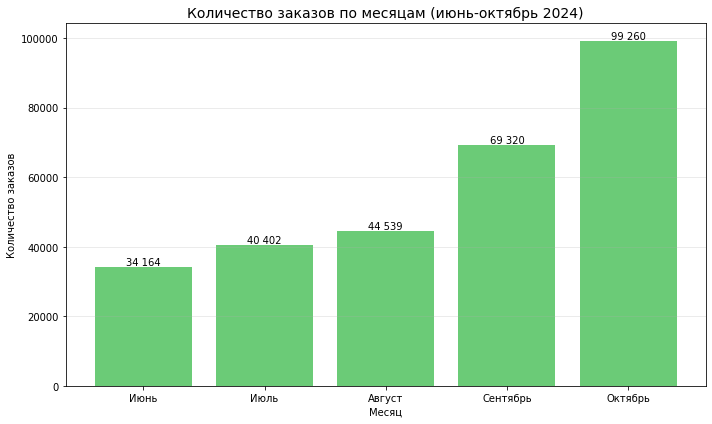

In [24]:
# Создаем копию датафрейма для работы
df = orders_final.copy()

# Смотрим динамику заказов по месяцам ---
monthly_orders = df.groupby('month').size().reset_index(name='orders_count')
monthly_orders['month_name'] = monthly_orders['month'].map({
    6: 'Июнь', 7: 'Июль', 8: 'Август', 9: 'Сентябрь', 10: 'Октябрь'
})

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#6BCB77']
bars = ax.bar(monthly_orders['month_name'], monthly_orders['orders_count'], color=colors)
ax.set_title('Количество заказов по месяцам (июнь-октябрь 2024)', fontsize=14)
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество заказов')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}'.replace(',', ' '),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

3.1.2. Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу.


--- Распределение по типам мероприятий  ---
Доли по типам мероприятий (%):


event_type_main,выставки,другое,концерты,спорт,стендап,театр,ёлки
season,,,,,,,
лето,2.0,27.2,42.6,2.5,5.3,20.1,0.2
осень,1.4,19.7,37.2,11.2,4.1,25.3,1.0


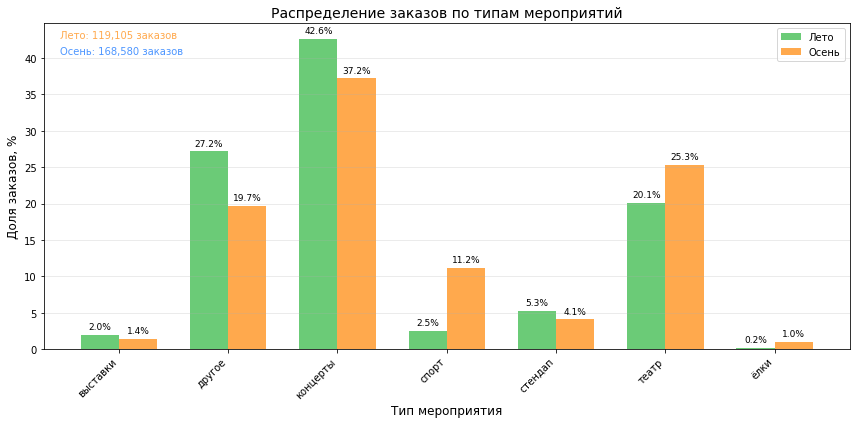

In [25]:
# Сравнение долей заказов по категориям (лето vs осень)
# 1. Сравниваем по типам мероприятий 

# Функция для расчета долей
def calculate_shares(data, group_col):
    """Рассчитывает долю каждой категории в разрезе сезонов"""
    cross_tab = pd.crosstab(data['season'], data[group_col], margins=False)
    shares = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
    return shares

print("\n--- Распределение по типам мероприятий  ---")
event_shares = calculate_shares(df, 'event_type_main')
print("Доли по типам мероприятий (%):")
display(event_shares.round(1))

# Визуализация (столбчатая диаграмма)
fig, ax = plt.subplots(figsize=(12, 6))

# Настройки для группированной столбчатой диаграммы
categories = event_shares.columns.tolist()
x = np.arange(len(categories))
width = 0.35

# Данные для лета и осени
summer_values = event_shares.loc['лето'].values
autumn_values = event_shares.loc['осень'].values

# Столбцы
bars1 = ax.bar(x - width/2, summer_values, width, label='Лето', color='#6BCB77')
bars2 = ax.bar(x + width/2, autumn_values, width, label='Осень', color='#FFA94D')

# Настройка графика
ax.set_xlabel('Тип мероприятия', fontsize=12)
ax.set_ylabel('Доля заказов, %', fontsize=12)
ax.set_title('Распределение заказов по типам мероприятий', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Добавляем подписи с количеством заказов
summer_total = len(df[df['season'] == 'лето'])
autumn_total = len(df[df['season'] == 'осень'])
ax.text(0.02, 0.98, f'Лето: {summer_total:,} заказов', 
        transform=ax.transAxes, fontsize=10, color='#FFA94D', verticalalignment='top')
ax.text(0.02, 0.93, f'Осень: {autumn_total:,} заказов', 
        transform=ax.transAxes, fontsize=10, color='#4D96FF', verticalalignment='top')

plt.tight_layout()
plt.show()


---  Распределение по типам устройств ---
Доли по типам устройств (%):


device_type_canonical,desktop,mobile
season,,
лето,19.4,80.6
осень,20.3,79.7


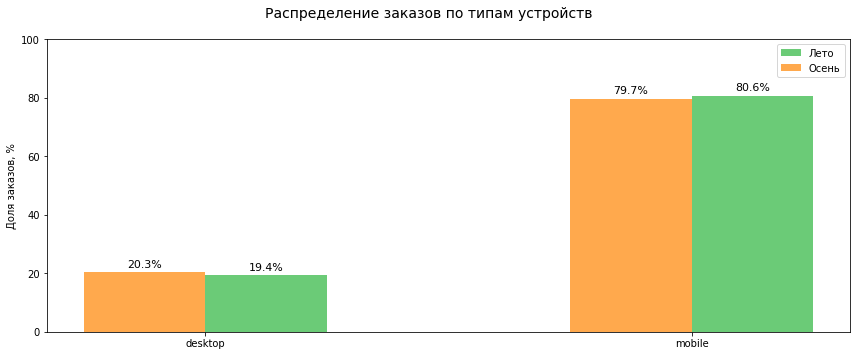

In [26]:
# 2.Сравнение по типам устройств ---
print("\n---  Распределение по типам устройств ---")
device_shares = calculate_shares(df, 'device_type_canonical')
print("Доли по типам устройств (%):")
display(device_shares.round(1))

# Визуализация
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#6BCB77', '#FFA94D']
width = 0.25  # Ширина полос

for idx, season in enumerate(['лето', 'осень']):
    data = device_shares.loc[season]
    bars = ax.bar(data.index, data.values, color=colors[idx], width=(-width if idx else width), align='edge')
    ax.set_ylabel('Доля заказов, %')
    ax.set_ylim(0, 100)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11)

    ax.legend(['Лето', 'Осень'], loc='upper right')

plt.suptitle('Распределение заказов по типам устройств', fontsize=14)
plt.tight_layout()
plt.show()



--- Распределение по возрастным рейтингам ---
Доли по возрастным рейтингам (%):


age_limit,0,6,12,16,18
season,,,,,
лето,18.0,18.2,20.5,28.3,15.0
осень,23.6,17.6,22.1,26.2,10.4


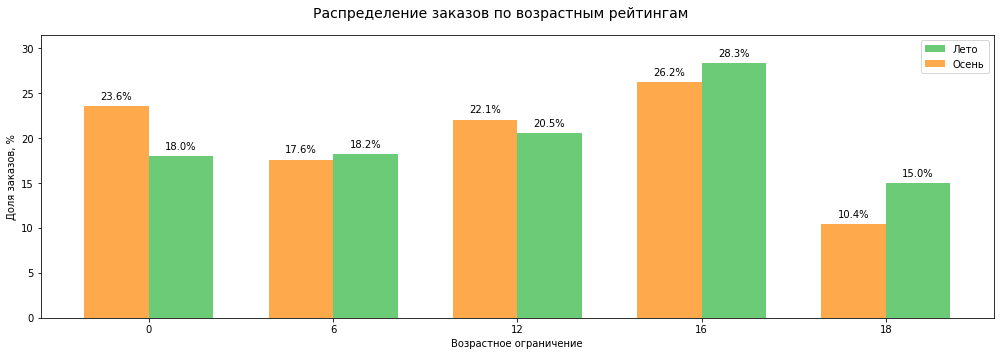

In [27]:
# Сравниваем по возрастным рейтингам
print("\n--- Распределение по возрастным рейтингам ---")
age_shares = calculate_shares(df, 'age_limit')
print("Доли по возрастным рейтингам (%):")
display(age_shares.round(1))

# Визуализация
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#6BCB77', '#FFA94D']
width = 0.35  # Ширина полос

for idx, season in enumerate(['лето', 'осень']):
    data = age_shares.loc[season].sort_index()
    bars = ax.bar(data.index.astype(str), data.values, color=colors[idx], width=(-width if idx else width), align='edge')
    ax.set_xlabel('Возрастное ограничение')
    ax.set_ylabel('Доля заказов, %')
    ax.set_ylim(0, max(data.values) * 1.2)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

    ax.legend(['Лето', 'Осень'], loc='upper right')

plt.suptitle('Распределение заказов по возрастным рейтингам', fontsize=14)
plt.tight_layout()
plt.show()


3.1.3 Изучите изменение выручки с продажи одного билета 


--- Анализ выручки с одного билета ---
Средняя выручка с одного билета по типам мероприятий (лето vs осень):


season,лето,осень,change_%,change_rub
event_type_main,,,,
выставки,86.416199,90.603607,4.800000,4.200000
другое,77.437408,76.115334,-1.700000,-1.300000
концерты,304.712219,268.082367,-12.000000,-36.599998
спорт,50.761833,49.969734,-1.600000,-0.800000
стендап,218.518112,231.124969,5.800000,12.600000
театр,214.126328,175.977081,-17.799999,-38.099998
ёлки,271.436188,229.585587,-15.400000,-41.900002


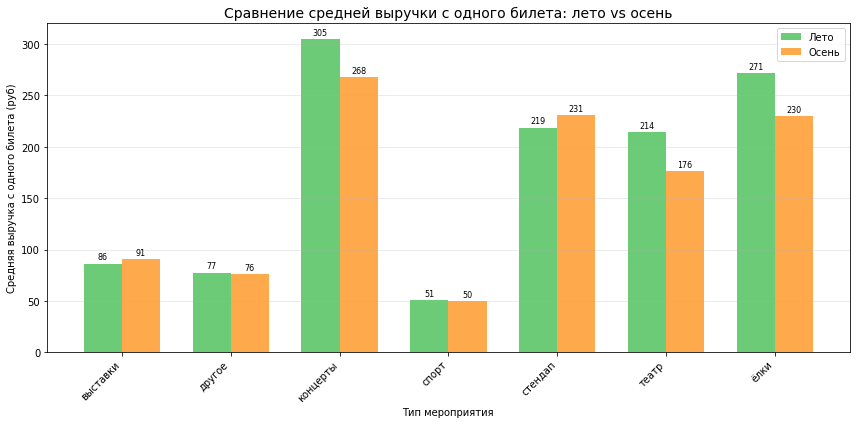

In [28]:
# Считаем изменение выручки с одного билета по типам мероприятия лето/осень
print("\n--- Анализ выручки с одного билета ---")

# Группировка по сезону и типу мероприятия
ticket_revenue = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().reset_index()

# Создаем таблицу для сравнения
pivot_ticket = ticket_revenue.pivot(index='event_type_main', columns='season', values='one_ticket_revenue_rub')
pivot_ticket['change_%'] = ((pivot_ticket['осень'] - pivot_ticket['лето']) / pivot_ticket['лето'] * 100).round(1)
pivot_ticket['change_rub'] = (pivot_ticket['осень'] - pivot_ticket['лето']).round(1)

print("Средняя выручка с одного билета по типам мероприятий (лето vs осень):")
display(pivot_ticket)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pivot_ticket.index))
width = 0.35

summer_values = pivot_ticket['лето'].values
autumn_values = pivot_ticket['осень'].values

bars1 = ax.bar(x - width/2, summer_values, width, label='Лето', color='#6BCB77')
bars2 = ax.bar(x + width/2, autumn_values, width, label='Осень', color='#FFA94D')

ax.set_xlabel('Тип мероприятия')
ax.set_ylabel('Средняя выручка с одного билета (руб)')
ax.set_title('Сравнение средней выручки с одного билета: лето vs осень', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(pivot_ticket.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bars, color in [(bars1, '#FFA94D'), (bars2, '#4D96FF')]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

<font color='green'>С наступлением осени (сентябрь–октябрь) по сравнению с летом (июнь–август) в структуре заказов наблюдаются следующие изменения:

По типам мероприятий:  

Существенно выросла доля спортивных событий (с 2,5 % до 11,2 %), что может отражать начало нового спортивного сезона.  

Увеличилась доля театральных постановок (с 20,1 % до 25,3 %) и ёлок (с 0,2 % до 1,0 %) – последнее связано с приближением новогоднего периода.  

Снизилась доля концертов (с 42,6 % до 37,2 %) и категории «другое» (с 27,2 % до 19,7 %).  

Доли выставок и стендапа изменились незначительно.  

По типу устройства:  

Распределение практически не изменилось: доля мобильных устройств остаётся на уровне ~80 %, десктопных – ~20 %. Мобильные устройства остаются доминирующим каналом заказов.  

По возрастному рейтингу:  

Заметно выросла доля заказов на мероприятия 0+ (с 18,0 % до 23,6 %), что, вероятно, связано с ростом детских и семейных событий осенью.

Снизилась доля мероприятий 18+ (с 15,0 % до 10,4 %) и 16+ (с 28,3 % до 26,2 %). Доли 6+ и 12+ остались примерно на том же уровне.  

Средняя выручка с одного билета по типам мероприятий изменилась разнонаправленно:  

Выросла для выставок (+4,8 %) и стендапа (+5,8 %).  

Снизилась для концертов (–12,0 %), театра (–17,8 %), ёлок (–15,4 %) и незначительно для категорий «другое» и спорт.  

Наиболее выраженное падение средней цены билета отмечено в театральном сегменте – возможно, из‑за появления более доступных спектаклей или акций.  

Таким образом, с наступлением осени меняется как структура спроса (в пользу спорта и театра), так и ценовая картина – билеты на некоторые популярные направления (концерты, театр) становятся в среднем дешевле, что может стимулировать рост числа заказов, наблюдаемый в осенние месяцы.  


</font>

3.2. Осенняя активность пользователей

In [29]:
# Анализ осенних ежедневнеых изменений 

print("\n" + "=" * 60)
print("3.2. ЕЖЕДНЕВНАЯ ДИНАМИКА ОСЕНЬЮ")
print("=" * 60)

# Отбираем осенние данные (сентябрь-октябрь)
df = orders_final.copy()
autumn_df = df[df['month'].isin([9, 10])].copy()

print(f"Осенний период: {len(autumn_df)} заказов")
print(f"Даты: с {autumn_df['created_dt_msk'].min()} по {autumn_df['created_dt_msk'].max()}")
print(f"Количество дней: {autumn_df['created_dt_msk'].dt.date.nunique()}")

# --- Делаем сводную таблицу по дням ---
print("\n--- Сводная таблица по дням ---")

# Группируем по дате
daily_stats = autumn_df.groupby(autumn_df['created_dt_msk'].dt.date).agg({
    'order_id': 'count',                    # общее число заказов
    'user_id': 'nunique',                   # количество активных пользователей (DAU)
    'one_ticket_revenue_rub': 'mean'        # средняя стоимость одного билета
}).reset_index()

# Переименовываем колонки
daily_stats.columns = ['date', 'orders_count', 'dau', 'avg_ticket_price']

# Рассчитываем среднее число заказов на одного пользователя
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']

print(f"Создана сводная таблица: {len(daily_stats)} дней")
print("\nПервые 5 дней:")
display(daily_stats.head())

print("\nПоследние 5 дней:")
display(daily_stats.tail())

# ---  Статистическое описание ---
print("\n--- Статистическое описание показателей ---")

print("Статистика по дням:")
display(daily_stats[['orders_count', 'dau', 'orders_per_user', 'avg_ticket_price']].describe())


3.2. ЕЖЕДНЕВНАЯ ДИНАМИКА ОСЕНЬЮ
Осенний период: 168580 заказов
Даты: с 2024-09-01 00:00:00 по 2024-10-31 00:00:00
Количество дней: 61

--- Сводная таблица по дням ---
Создана сводная таблица: 61 дней

Первые 5 дней:


,date,orders_count,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1327,564,200.168701,2.352837
1,2024-09-02,1380,574,189.464645,2.404181
2,2024-09-03,5111,778,80.130096,6.569409
3,2024-09-04,1772,685,177.785843,2.586861
4,2024-09-05,1944,739,189.510162,2.630582



Последние 5 дней:


,date,orders_count,dau,avg_ticket_price,orders_per_user
56,2024-10-27,2849,1034,186.968323,2.755319
57,2024-10-28,2838,985,170.654938,2.881218
58,2024-10-29,2835,998,177.366074,2.840681
59,2024-10-30,2927,1039,182.791489,2.817132
60,2024-10-31,5961,1272,150.530014,4.686321



--- Статистическое описание показателей ---
Статистика по дням:


,orders_count,dau,orders_per_user,avg_ticket_price
count,61.000000,61.000000,61.000000,61.000000
mean,2763.606557,923.393443,2.956616,183.104095
std,967.910951,143.404705,0.757641,21.787403
min,1327.000000,564.000000,2.327806,80.130096
25%,2313.000000,822.000000,2.703143,177.785843
50%,2649.000000,946.000000,2.779643,186.866837
75%,2910.000000,1025.000000,2.914393,196.208588
max,7288.000000,1272.000000,6.631483,208.771423



 Визуализация ежедневной динамики


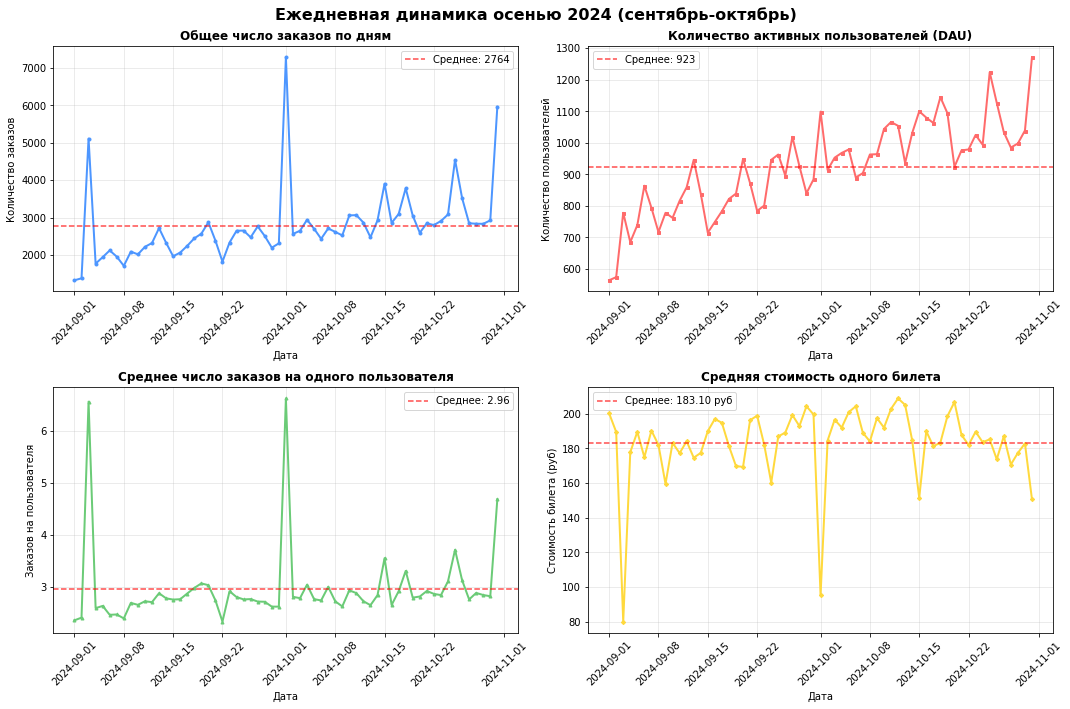

In [30]:
# Визуализируем ежедневную динамику 
print("\n Визуализация ежедневной динамики")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Общее число заказов по дням
ax = axes[0, 0]
ax.plot(daily_stats['date'], daily_stats['orders_count'], 
        color='#4D96FF', linewidth=2, marker='o', markersize=3)
ax.axhline(y=daily_stats['orders_count'].mean(), color='red', 
           linestyle='--', alpha=0.7, label=f"Среднее: {daily_stats['orders_count'].mean():.0f}")
ax.set_title('Общее число заказов по дням', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество заказов')
ax.grid(alpha=0.3)
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Количество активных пользователей (DAU)
ax = axes[0, 1]
ax.plot(daily_stats['date'], daily_stats['dau'], 
        color='#FF6B6B', linewidth=2, marker='s', markersize=3)
ax.axhline(y=daily_stats['dau'].mean(), color='red', 
           linestyle='--', alpha=0.7, label=f"Среднее: {daily_stats['dau'].mean():.0f}")
ax.set_title('Количество активных пользователей (DAU)', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество пользователей')
ax.grid(alpha=0.3)
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Среднее число заказов на одного пользователя
ax = axes[1, 0]
ax.plot(daily_stats['date'], daily_stats['orders_per_user'], 
        color='#6BCB77', linewidth=2, marker='^', markersize=3)
ax.axhline(y=daily_stats['orders_per_user'].mean(), color='red', 
           linestyle='--', alpha=0.7, label=f"Среднее: {daily_stats['orders_per_user'].mean():.2f}")
ax.set_title('Среднее число заказов на одного пользователя', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Заказов на пользователя')
ax.grid(alpha=0.3)
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Средняя стоимость одного билета
ax = axes[1, 1]
ax.plot(daily_stats['date'], daily_stats['avg_ticket_price'], 
        color='#FFD93D', linewidth=2, marker='D', markersize=3)
ax.axhline(y=daily_stats['avg_ticket_price'].mean(), color='red', 
           linestyle='--', alpha=0.7, label=f"Среднее: {daily_stats['avg_ticket_price'].mean():.2f} руб")
ax.set_title('Средняя стоимость одного билета', fontsize=12, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Стоимость билета (руб)')
ax.grid(alpha=0.3)
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Ежедневная динамика осенью 2024 (сентябрь-октябрь)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

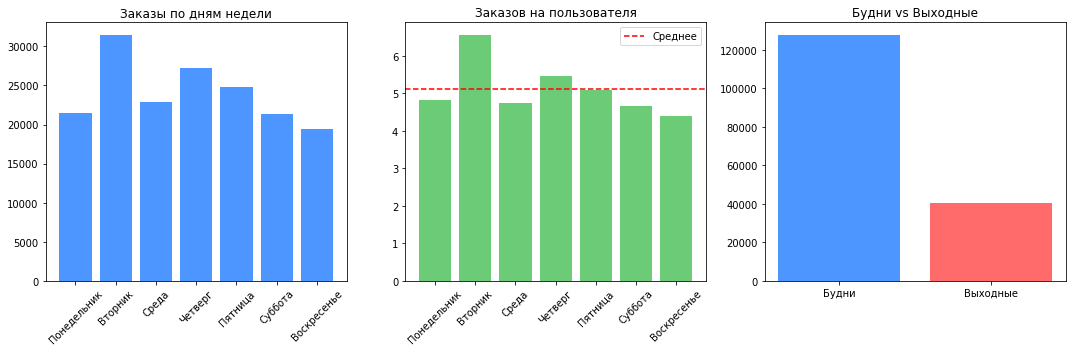

НЕДЕЛЬНАЯ ЦИКЛИЧНОСТЬ
Пик активности: Вторник (31,479 заказов)
Спад активности: Воскресенье (19,388 заказов)

Будни: 127,860 заказов
Выходные: 40,720 заказов
В выходные заказов на 68% МЕНЬШЕ, чем в будни

Заказов на пользователя:
  Будни: 9.68
  Выходные: 5.68


In [31]:
# Изучаем недельную цикличность
# Отбираем осенние данные
df = orders_final.copy()
autumn_df = df[df['month'].isin([9, 10])].copy()

# Добавляем день недели
autumn_df['day_name'] = autumn_df['created_dt_msk'].dt.day_name()
autumn_df['day_week'] = autumn_df['created_dt_msk'].dt.dayofweek

# Переводим на русский для удобного отображения на графике
days_ru = {
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
}
autumn_df['day_name'] = autumn_df['day_name'].map(days_ru)

# Сводка по дням недели
weekly = autumn_df.groupby(['day_week', 'day_name']).agg({
    'order_id': 'count',
    'user_id': 'nunique',
    'one_ticket_revenue_rub': 'mean'
}).reset_index()
weekly.columns = ['day_week', 'day_name', 'orders', 'users', 'avg_price']
weekly['orders_per_user'] = weekly['orders'] / weekly['users']
weekly = weekly.sort_values('day_week')

# Будни / выходные
autumn_df['weekend'] = autumn_df['day_week'].isin([5, 6])
weekend_comp = autumn_df.groupby('weekend').agg({
    'order_id': 'count',
    'user_id': 'nunique',
    'one_ticket_revenue_rub': 'mean'
})
weekend_comp['orders_per_user'] = weekend_comp['order_id'] / weekend_comp['user_id']
weekend_comp.index = ['Будни', 'Выходные']

# Строим визуализацию
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Заказы по дням недели
axes[0].bar(weekly['day_name'], weekly['orders'], color='#4D96FF')
axes[0].set_title('Заказы по дням недели')
axes[0].tick_params(axis='x', rotation=45)

# 2. Заказы на пользователя
axes[1].bar(weekly['day_name'], weekly['orders_per_user'], color='#6BCB77')
axes[1].axhline(y=weekly['orders_per_user'].mean(), color='red', linestyle='--', label='Среднее')
axes[1].set_title('Заказов на пользователя')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# 3. Будни vs выходные
axes[2].bar(weekend_comp.index, weekend_comp['order_id'], color=['#4D96FF', '#FF6B6B'])
axes[2].set_title('Будни vs Выходные')

plt.tight_layout()
plt.show()
 
print("=" * 50)
print("НЕДЕЛЬНАЯ ЦИКЛИЧНОСТЬ")
print("=" * 50)

print(f"Пик активности: {weekly.loc[weekly['orders'].idxmax(), 'day_name']} ({weekly['orders'].max():,} заказов)")
print(f"Спад активности: {weekly.loc[weekly['orders'].idxmin(), 'day_name']} ({weekly['orders'].min():,} заказов)")

print(f"\nБудни: {weekend_comp.loc['Будни', 'order_id']:,} заказов")
print(f"Выходные: {weekend_comp.loc['Выходные', 'order_id']:,} заказов")

weekend_orders = weekend_comp.loc['Выходные', 'order_id']
weekday_orders = weekend_comp.loc['Будни', 'order_id']

if weekend_orders > weekday_orders:
    diff_pct = ((weekend_orders - weekday_orders) / weekday_orders * 100)
    print(f"В выходные заказов на {diff_pct:.0f}% БОЛЬШЕ, чем в будни")
else:
    diff_pct = ((weekday_orders - weekend_orders) / weekday_orders * 100)
    print(f"В выходные заказов на {diff_pct:.0f}% МЕНЬШЕ, чем в будни")

print(f"\nЗаказов на пользователя:")
print(f"  Будни: {weekend_comp.loc['Будни', 'orders_per_user']:.2f}")
print(f"  Выходные: {weekend_comp.loc['Выходные', 'orders_per_user']:.2f}")

<font color='green'>Осенняя активность пользователей характеризуется постепенным ростом числа заказов и пользователей к концу октября. Выявленная недельная цикличность с пиками в будние дни и спадом в выходные может объясняться тем, что пользователи чаще бронируют билеты на будущие выходные мероприятия в течение рабочей недели, а также активностью корпоративных заказов.  

Таким образом, осенью наблюдается устойчивый рост пользовательского спроса, что подтверждает сезонный фактор. Продуктовой команде следует учитывать, что будние дни – ключевое время для привлечения заказов, и стоит усиливать маркетинговую активность именно в этот период.


</font>

3.3. Популярные события и партнёры

ТОП-5 РЕГИОНОВ ПО ЗАКАЗАМ:


,region_name,events,orders,revenue,events_%,orders_%
23,Каменевский регион,5935,89662,55908256.0,26.5,31.2
60,Североярская область,3800,43737,22102084.0,17.0,15.2
77,Широковская область,1232,16169,8628101.0,5.5,5.6
42,Медовская область,504,13892,2927650.0,2.3,4.8
45,Озернинский край,349,10348,9407522.0,1.6,3.6



Всего регионов: 81
Лидер: Каменевский регион   89,662 заказов
ТОП-5 ПАРТНЁРОВ ПО ВЫРУЧКЕ:


,service_name,events,orders,revenue,orders_%,revenue_%,avg_check
3,Билеты без проблем,4247,62830,24255224.0,21.8,16.299999,386.05
24,Мой билет,1300,34439,22042028.0,12.0,14.800000,640.03
25,Облачко,2335,26402,18588614.0,9.2,12.500000,704.06
21,Лови билет!,4867,40798,16668712.0,14.2,11.200000,408.57
8,Весь в билетах,855,16409,16493785.0,5.7,11.100000,1005.17



Всего партнёров: 36
Лидер: Билеты без проблем   24,255,224 руб


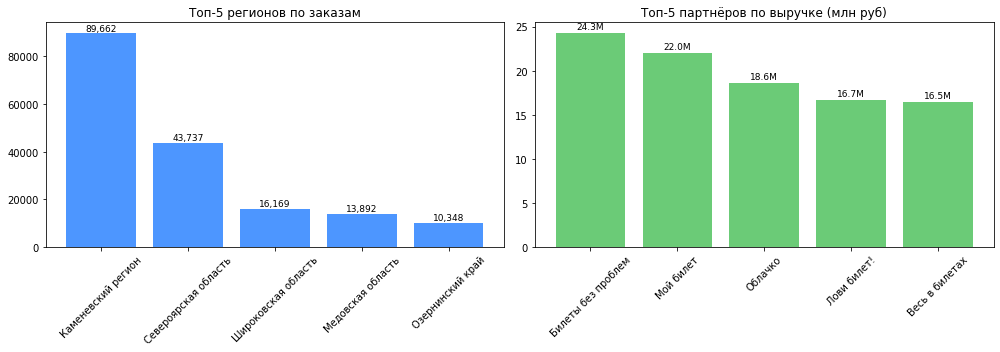

• Топ-3 региона дают 52.0% всех заказов
• Топ-3 партнёра дают 43.5% всей выручки
• Регион с наибольшим разнообразием: Каменевский регион (5935 событий)
• Партнёр с самым высоким чеком: Дырокол (1487 руб/заказ)


In [32]:
# Считаем популярные события и партнеров
# Создаем датафрейм
df = orders_final.copy()

# Считаем статистику по регионам
region = df.groupby('region_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('revenue_rub', 'sum')
).reset_index()

# Добавляем доли
region['events_%'] = (region['events'] / region['events'].sum() * 100).round(1)
region['orders_%'] = (region['orders'] / region['orders'].sum() * 100).round(1)
region = region.sort_values('orders', ascending=False)

# Топ-5 регионов
print("ТОП-5 РЕГИОНОВ ПО ЗАКАЗАМ:")
display(region.head(5))

print(f"\nВсего регионов: {len(region)}")
print(f"Лидер: {region.iloc[0]['region_name']}   {region.iloc[0]['orders']:,} заказов")


# Считаем статистику по партнёрам
partner = df.groupby('service_name').agg(
    events=('event_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('revenue_rub', 'sum')
).reset_index()

# Добавляем доли и средний чек
partner['orders_%'] = (partner['orders'] / partner['orders'].sum() * 100).round(1)
partner['revenue_%'] = (partner['revenue'] / partner['revenue'].sum() * 100).round(1)
partner['avg_check'] = (partner['revenue'] / partner['orders']).round(2)
partner = partner.sort_values('revenue', ascending=False)


# Топ-5 партнёров
print("ТОП-5 ПАРТНЁРОВ ПО ВЫРУЧКЕ:")
display(partner.head(5))

print(f"\nВсего партнёров: {len(partner)}")
print(f"Лидер: {partner.iloc[0]['service_name']}   {partner.iloc[0]['revenue']:,.0f} руб")

# Строим визуализации 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Топ-5 регионов по заказам
ax = axes[0]
top_regions = region.head(5)
bars = ax.bar(top_regions['region_name'], top_regions['orders'], color='#4D96FF')
ax.set_title('Топ-5 регионов по заказам', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# График 2: Топ-5 партнёров по выручке
ax = axes[1]
top_partners = partner.head(5)
bars = ax.bar(top_partners['service_name'], top_partners['revenue'] / 1_000_000, color='#6BCB77')
ax.set_title('Топ-5 партнёров по выручке (млн руб)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}M', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


top3_regions = region.head(3)['orders'].sum() / region['orders'].sum() * 100
top3_partners = partner.head(3)['revenue'].sum() / partner['revenue'].sum() * 100

print(f"• Топ-3 региона дают {top3_regions:.1f}% всех заказов")
print(f"• Топ-3 партнёра дают {top3_partners:.1f}% всей выручки")
print(f"• Регион с наибольшим разнообразием: {region.loc[region['events'].idxmax(), 'region_name']} ({region['events'].max()} событий)")
print(f"• Партнёр с самым высоким чеком: {partner.loc[partner['avg_check'].idxmax(), 'service_name']} ({partner['avg_check'].max():.0f} руб/заказ)")

<font color='green'>Всего 81 регион, но топ-3 (Каменевский регион, Североярская область, Широковская область) обеспечивают 52% всех заказов.  

Каменевский регион – абсолютный лидер: 31,2% заказов и наибольшее разнообразие мероприятий (5935 событий).  

Среди 36 партнёров топ-3 («Билеты без проблем», «Мой билет», «Облачко») аккумулируют 43,5% всей выручки.  

Лидер по выручке – «Билеты без проблем» (24,2 млн руб.), самый высокий средний чек – у «Дырокола» (1487 руб./заказ).  

Распределение крайне неравномерно: наблюдается «длинный хвост» из множества мелких игроков.  

Рекомендация: укреплять сотрудничество с топ-партнёрами и одновременно развивать регионы со средним потенциалом для снижения зависимости от нескольких ключевых точек.  
</font>

# 4. Статистический анализ данных

Проверим две гипотезы относительно активности пользователей мобильных и стационарных устройств, которые предполагают большую активность пользователей мобильных устройств:  

Гипотеза 1:  
•	Альтернативная гипотеза (Н1): Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.  
•	Нулевая (H₀):  Среднее количество заказов на одного пользователя мобильного приложения меньше или равно среднему количеству заказов у пользователей стационарных устройств. μ_mobile_orders ≤ μ_desktop_orders 

Гипотеза 2:  
•	Альтернативная гипотеза (Н1): Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.  
•	Нулевая (H₀):  Среднее время между заказами пользователей мобильных приложений меньше или равно среднему времени между заказами у пользователей стационарных устройств. μ_mobile_time ≤ μ_desktop_time 


In [33]:
# Готовим данные для исследования
# Подготовка данных
autumn_df = orders_final[orders_final['month'].isin([9, 10])].copy()

user_orders = autumn_df.groupby(['user_id', 'device_type_canonical']).agg(
    orders_count=('order_id', 'count'),
    avg_time=('days_since_prev', 'mean')
).reset_index()

# Разделяем на группы
mobile = user_orders[user_orders['device_type_canonical'] == 'mobile']
desktop = user_orders[user_orders['device_type_canonical'] == 'desktop']

mobile_time = mobile['avg_time'].dropna()
desktop_time = desktop['avg_time'].dropna()

print(f"\nРазмер выборок:")
print(f"  Mobile: {len(mobile)} пользователей")
print(f"  Desktop: {len(desktop)} пользователей")
print(f"  Пользователей с >1 заказа: mobile={len(mobile_time)}, desktop={len(desktop_time)}")

# Статистика по группам
print("\n Заказы на пользователя ")
print(f"  Mobile: среднее={mobile['orders_count'].mean():.2f}, медиана={mobile['orders_count'].median():.0f}")
print(f"  Desktop: среднее={desktop['orders_count'].mean():.2f}, медиана={desktop['orders_count'].median():.0f}")

print("\n Время между заказами (дни) ")
print(f"  Mobile: среднее={mobile_time.mean():.2f}, медиана={mobile_time.median():.2f}")
print(f"  Desktop: среднее={desktop_time.mean():.2f}, медиана={desktop_time.median():.2f}")


Размер выборок:
  Mobile: 14188 пользователей
  Desktop: 4868 пользователей
  Пользователей с >1 заказа: mobile=10192, desktop=4033

 Заказы на пользователя 
  Mobile: среднее=9.46, медиана=2
  Desktop: среднее=7.05, медиана=2

 Время между заказами (дни) 
  Mobile: среднее=20.63, медиана=9.50
  Desktop: среднее=14.86, медиана=4.50


In [34]:
# Проводим выбор статистического теста
# Проверка нормальности (выборка до 5000)
mobile_sample = mobile['orders_count'].sample(min(5000, len(mobile)), random_state=42)
desktop_sample = desktop['orders_count'].sample(min(5000, len(desktop)), random_state=42)

_, p_shapiro_mobile = shapiro(mobile_sample)
_, p_shapiro_desktop = shapiro(desktop_sample)

print("\n Проверка нормальности (тест Шапиро-Уилка) ")
print(f"  Mobile: p-value = {p_shapiro_mobile} {'(НЕ нормальное)' if p_shapiro_mobile < 0.05 else '(нормальное)'}")
print(f"  Desktop: p-value = {p_shapiro_desktop} {'(НЕ нормальное)' if p_shapiro_desktop < 0.05 else '(нормальное)'}")

if p_shapiro_mobile < 0.05 or p_shapiro_desktop < 0.05:
    print("\n   Данные НЕ распределены нормально (p < 0.05)")

# Проверка равенства дисперсий (тест Левене)
_, p_levene = levene(mobile_sample, desktop_sample)
print(f"\n Проверка равенства дисперсий (тест Левене) ")
print(f"  p-value = {p_levene}")
print(f"  Дисперсии: {'НЕ равны' if p_levene < 0.05 else 'равны'}")


 Проверка нормальности (тест Шапиро-Уилка) 
  Mobile: p-value = 0.0 (НЕ нормальное)
  Desktop: p-value = 0.0 (НЕ нормальное)

   Данные НЕ распределены нормально (p < 0.05)

 Проверка равенства дисперсий (тест Левене) 
  p-value = 0.10764503605180376
  Дисперсии: равны


<font color='green'>Обоснование выбора теста
1. Сравниваем две независимые группы (mobile vs desktop)
2. Данные НЕ распределены нормально → используем непараметрический тест
3. Для надежности используем ДВА теста:
   - t-тест Стьюдента (параметрический, устойчив к нарушениям при большом объеме)
   - U-тест Манна-Уитни (непараметрический, не требует нормальности)
4. Оба теста — односторонние, так как проверяем: μ_mobile > μ_desktop
</font>

In [35]:
# Проверяем гипотезу 1


print("ГИПОТЕЗА 1: ЗАКАЗЫ НА ПОЛЬЗОВАТЕЛЯ")
print("""
Формулировка гипотез:
H₀: μ_mobile ≤ μ_desktop (мобильные пользователи НЕ активнее)
H₁: μ_mobile > μ_desktop (мобильные пользователи активнее)
""")

# t-тест Стьюдента
t_stat, p_value_ttest = ttest_ind(
    mobile['orders_count'], 
    desktop['orders_count'], 
    equal_var=(p_levene >= 0.05), 
    alternative='greater'
)

# U-тест Манна-Уитни
u_stat, p_value_mw = mannwhitneyu(
    mobile['orders_count'], 
    desktop['orders_count'], 
    alternative='greater'
)

print(f"t-тест Стьюдента:")
print(f"  t-статистика = {t_stat:.6f}")
print(f"  p-value = {p_value_ttest}")

print(f"\nU-тест Манна-Уитни:")
print(f"  U-статистика = {u_stat:.0f}")
print(f"  p-value = {p_value_mw}")

# Принятие решения
if p_value_ttest < 0.05 and p_value_mw < 0.05:
    print(f"\n ОТВЕРГАЕМ H₀ (p < 0.05)")
    print(f"   → Среднее число заказов у mobile ({mobile['orders_count'].mean():.2f})")
    print(f"     статистически значимо ВЫШЕ, чем у desktop ({desktop['orders_count'].mean():.2f})")
    h1_result = True
else:
    print(f"\n НЕ ОТВЕРГАЕМ H₀ (p >= 0.05)")
    print(f"   → Статистически значимых различий НЕТ")
    h1_result = False

ГИПОТЕЗА 1: ЗАКАЗЫ НА ПОЛЬЗОВАТЕЛЯ

Формулировка гипотез:
H₀: μ_mobile ≤ μ_desktop (мобильные пользователи НЕ активнее)
H₁: μ_mobile > μ_desktop (мобильные пользователи активнее)

t-тест Стьюдента:
  t-статистика = 2.369228
  p-value = 0.00891759525968675

U-тест Манна-Уитни:
  U-статистика = 36106382
  p-value = 3.5483687326377004e-07

 ОТВЕРГАЕМ H₀ (p < 0.05)
   → Среднее число заказов у mobile (9.46)
     статистически значимо ВЫШЕ, чем у desktop (7.05)


In [36]:
# Проверяем гипотезу 2
print("ГИПОТЕЗА 2: ВРЕМЯ МЕЖДУ ЗАКАЗАМИ")
print("""
Формулировка гипотез:
H₀: μ_mobile ≤ μ_desktop (время между заказами НЕ больше)
H₁: μ_mobile > μ_desktop (время между заказами БОЛЬШЕ)
""")

# t-тест Стьюдента
t_stat, p_value_ttest = ttest_ind(
    mobile_time, 
    desktop_time, 
    equal_var=(p_levene >= 0.05), 
    alternative='greater'
)

# U-тест Манна-Уитни
u_stat, p_value_mw = mannwhitneyu(
    mobile_time, 
    desktop_time, 
    alternative='greater'
)

print(f"t-тест Стьюдента:")
print(f"  t-статистика = {t_stat:.6f}")
print(f"  p-value = {p_value_ttest}")

print(f"\nU-тест Манна-Уитни:")
print(f"  U-статистика = {u_stat:.0f}")
print(f"  p-value = {p_value_mw}")

# Принятие решения
if p_value_ttest < 0.05 and p_value_mw < 0.05:
    print(f"\n ОТВЕРГАЕМ H₀ (p < 0.05)")
    print(f"   → Среднее время между заказами у mobile ({mobile_time.mean():.2f} дней)")
    print(f"     статистически значимо ВЫШЕ, чем у desktop ({desktop_time.mean():.2f} дней)")
    h2_result = True
else:
    print(f"\n НЕ ОТВЕРГАЕМ H₀ (p >= 0.05)")
    print(f"   → Статистически значимых различий НЕТ")
    h2_result = False

ГИПОТЕЗА 2: ВРЕМЯ МЕЖДУ ЗАКАЗАМИ

Формулировка гипотез:
H₀: μ_mobile ≤ μ_desktop (время между заказами НЕ больше)
H₁: μ_mobile > μ_desktop (время между заказами БОЛЬШЕ)

t-тест Стьюдента:
  t-статистика = 11.688780
  p-value = 1.0124626808622743e-31

U-тест Манна-Уитни:
  U-статистика = 23901146
  p-value = 2.0735692985028166e-52

 ОТВЕРГАЕМ H₀ (p < 0.05)
   → Среднее время между заказами у mobile (20.63 дней)
     статистически значимо ВЫШЕ, чем у desktop (14.86 дней)


<font color='green'>

1. ГИПОТЕЗА 1 (заказы на пользователя):  ПОДТВЕРЖДЕНА  
   Мобильные пользователи совершают статистически значимо БОЛЬШЕ заказов, чем пользователи десктопных устройств.  
   Среднее: mobile = 9.46 vs desktop = 7.05  
    
2. ГИПОТЕЗА 2 (время между заказами):  ПОДТВЕРЖДЕНА  
   Время между заказами у мобильных пользователей статистически значимо БОЛЬШЕ, чем у десктопных пользователей.  
   Среднее: mobile = 20.63 дней vs desktop = 14.86 дней  

3. ОБЩИЙ ВЫВОД:  
   Мобильные пользователи активнее в плане количества покупок, но при этом между их заказами проходит больше времени, чем у десктопных.  
    </font>

# 5. Общий вывод и рекомендации

**Информация о данных** 



В работе использованы данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Исходный датафрейм содержал 290 849 заказов, после предобработки (удаление дубликатов, выбросов по 99-му перцентилю, объединение с событиями) в финальный анализ вошло 287 685 заказов. Данные включают информацию о пользователях, мероприятиях, типах устройств, выручке (в рублях и тенге, с конвертацией в рубли), регионах и билетных операторах.

**Основные результаты анализа**  

`Сезонные изменения и популярность мероприятий`   
Рост заказов: количество заказов увеличилось с 34 164 в июне до 99 260 в октябре – рост в 2,9 раза. Осенью совершено 58,6% всех заказов за исследуемый период.

Изменение структуры спроса:  
Спорт – доля выросла с 2,5% до 11,2% (начало спортивного сезона).  
Театр – доля увеличилась с 20,1% до 25,3%.  
Концерты – доля снизилась с 42,6% до 37,2%.  
Мобильные устройства стабильно доминируют – ~80% заказов.  

Возрастной состав: осенью растёт доля мероприятий 0+ (с 18% до 23,6%), снижается доля 18+ (с 15% до 10,4%).  

Изменение стоимости билета:  
Средняя выручка с одного билета снизилась для концертов (–12%), театра (–17,8%) и ёлок (–15,4%).  
Выросла для выставок (+4,8%) и стендапа (+5,8%).  
В целом осенью билеты становятся доступнее, что стимулирует рост числа заказов.  

`Пользовательская активность осенью`  
В среднем в день – 2 764 заказа, 923 активных пользователя.  
Среднее число заказов на пользователя – 2,96.  
Средняя стоимость билета – 183 рубля.  
Недельная цикличность: в будние дни заказов в 3 раза больше, чем в выходные. Наиболее активный день – вторник, наименее – воскресенье.  

`Регионы и партнёры`  
Регионы: из 81 региона топ-3 (Каменевский регион, Североярская область, Широковская область) дают 52% всех заказов. Каменевский регион – лидер с 31,2% заказов и наибольшим разнообразием мероприятий (5 935 событий).  

Партнёры: из 36 операторов топ-3 («Билеты без проблем», «Мой билет», «Облачко») аккумулируют 43,5% выручки.  
Наблюдается высокая концентрация – «длинный хвост» из множества мелких игроков. 

**Результаты проверки гипотез**

Гипотеза 1 (заказы на пользователя): ПОДТВЕРЖДЕНА ✅
Среднее число заказов на пользователя у mobile (9,46) статистически значимо выше, чем у desktop (7,05).
p < 0,05 для обоих тестов (t-тест и U-тест Манна-Уитни).
Гипотеза 2 (время между заказами): ПОДТВЕРЖДЕНА ✅
Среднее время между заказами у mobile (20,63 дня) статистически значимо выше, чем у desktop (14,86 дня).
p < 0,001 для обоих тестов.

Интерпретация: мобильные пользователи активнее по числу покупок, но делают их реже – вероятно, планируют досуг на больший период вперёд.

**Рекомендации**

- Усилить мобильное направление. Мобильные пользователи – основа аудитории (~80% заказов) и статистически более активны. Инвестировать в улучшение мобильного приложения, push-уведомления и персонализацию.  

- Сделать акцент на будние дни. В будние дни заказов в 3 раза больше, чем в выходные. Запускать специальные предложения и рекламные кампании во вторник–четверг.  

- Адаптировать ассортимент под осенний сезон. Осенью растёт спрос на театр и спорт. Расширять предложение в этих категориях, возможно, с более доступными ценами.  

- Укрепить сотрудничество с топ-партнёрами. Предоставлять эксклюзивные условия лидерам («Билеты без проблем», «Мой билет», «Облачко») для сохранения доли рынка.  

- Развивать регионы-«середняки». Снизить зависимость от одного-двух регионов, усиливая присутствие в регионах со средним потенциалом (например, Медовская область, Озернинский край).  

- Изучить причины успеха лидирующих партнёров. Адаптировать их практики (высокий чек у «Дырокола», большой объём у «Билеты без проблем») для других операторов.  

**Итог: осенью происходит сдвиг в предпочтениях аудитории, растёт активность и доступность билетов.Мобильные пользователи – ключевой сегмент, требующий приоритетного внимания.Полученные инсайты позволяют оптимизировать маркетинговые стратегии, ассортимент и партнёрские отношения для дальнейшего роста сервиса.**